# Qwen3-VL Decoder-Only SFT Plan

이 노트북은 `detect-and-reason` 안에서 `merge` 데이터를 사용해 **Qwen3-VL decoder-only SFT baseline**을 준비하는 용도다.

목표:
- 1차는 **LLM decoder에만 LoRA**를 걸고 `ViT`와 `aligner(projector)`는 freeze
- 학습 데이터는 `merge 3cls` COCO annotation에서 직접 만들고, detector와 분리된 VLM 학습 파이프라인을 확보
- 이후 필요하면 같은 데이터 포맷 위에서 `aligner` 또는 `vision encoder`까지 확장

왜 `ms-swift`를 먼저 쓰는가:
- Qwen 공식 문서가 Qwen3 학습 경로로 `ms-swift`를 적극 안내: https://qwen.readthedocs.io/en/latest/training/ms_swift.html
- Qwen 공식 `LLaMA-Factory` 페이지는 현재도 `To be updated for Qwen3`라고 적혀 있음: https://qwen.readthedocs.io/en/latest/training/llama_factory.html
- `ms-swift`는 멀티모달에서 `freeze_vit`, `freeze_aligner`, `freeze_llm`를 바로 제어할 수 있어 지금 목표와 잘 맞음: https://github.com/modelscope/ms-swift/blob/main/docs/source_en/Instruction/Command-line-parameters.md
- `TRL`이 죽은 건 아니지만, 지금 목표인 `Qwen3-VL + decoder-only first + later expansion`에는 `ms-swift` 쪽이 더 직접적임

LoRA가 뜻하는 것:
- 원본 큰 가중치를 전부 다시 학습하는 대신, 대상 선형층에 작은 저랭크 행렬을 추가로 붙여서 그것만 학습
- 그래서 메모리와 저장 비용이 줄고, 나중에 `decoder-only -> projector 추가 -> vision 추가`처럼 단계적으로 확장하기 좋음
- 이번 baseline은 `target_modules=all-linear` + `freeze_vit=true` + `freeze_aligner=true` 조합으로 **LLM 쪽에만 adapter**를 붙이는 방향으로 잡는다

참고:
- `ms-swift` 문서상 **QLoRA는 merge 후 vLLM 가속 추론 경로와 맞지 않으므로**, 나중에 `vLLM`까지 고려하면 우선은 plain `LoRA`가 낫다.
- 관련 문서: https://swift.readthedocs.io/en/latest/Instruction/Pre-training-and-Fine-tuning.html

In [29]:
import os
import sys
import json
import shlex
import shutil
import subprocess
import importlib.util
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
from PIL import Image, ImageOps

CWD = Path.cwd().resolve()
if (CWD / "src").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "src").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = Path("/home/hyeonjin/detect-and-reason").resolve()

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config_loader import load_yaml, output_name_for_rfdetr
from src.vlm.config import load_vlm_config
from src.vlm.cropping import load_crop
from src.vlm import prompting as prompt_module
from src.vlm.schema import normalize_prediction_label

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"PYTHON       = {sys.executable}")

PROJECT_ROOT = /home/hyeonjin/detect-and-reason
PYTHON       = /home/hyeonjin/detect-and-reason/.venv/bin/python


## Controls

기본값은 안전하게 잡아둔다.

- `RUN_CONVERSION=False`: crop 이미지와 jsonl을 아직 만들지 않음
- `RUN_INSTALL_MS_SWIFT=False`: 설치 자동 실행 안 함
- `RUN_TRAINING=False`: 학습 자동 실행 안 함

먼저 preview와 command를 확인한 뒤, 마지막에 스위치만 켜서 실제 변환/학습을 돌리는 흐름이다.

In [44]:
DATASET_REF = "merge"
CLASS_MODE = "3cls"
MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"
VLM_CONFIG_REF = "qwen_finetune"

REASONING_STYLE = "template"  # "template" or "empty"
EXPAND_RATIO = 0.1
MIN_SIZE = 32

MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None

DATASET_OUTPUT_ROOT = PROJECT_ROOT / "data" / "vlm_sft" / f"{DATASET_REF}_{CLASS_MODE}_qwen3_vl_decoder"
CROP_OUTPUT_ROOT = DATASET_OUTPUT_ROOT / "crops"
TRAIN_JSONL = DATASET_OUTPUT_ROOT / "train.jsonl"
VAL_JSONL = DATASET_OUTPUT_ROOT / "val.jsonl"
MANIFEST_JSON = DATASET_OUTPUT_ROOT / "manifest.json"

RUN_CONVERSION = True
RUN_INSTALL_MS_SWIFT = False
RUN_TRAINING = True

USE_HF = True
TORCH_DTYPE = "bfloat16"
NUM_TRAIN_EPOCHS = 2
PER_DEVICE_TRAIN_BATCH_SIZE = 2
PER_DEVICE_EVAL_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 1e-4
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
MAX_LENGTH = 1024
DATASET_NUM_PROC = 4
SAVE_STEPS = 200
EVAL_STEPS = 200
LOGGING_STEPS = 10
SAVE_TOTAL_LIMIT = 2
MAX_PIXELS = None

TRAIN_OUTPUT_DIR = PROJECT_ROOT / "notebook" / "results" / "vlm_sft" / DATASET_REF / "qwen3_vl_4b_decoder_lora"

swift_spec = importlib.util.find_spec("swift")

def resolve_swift_cmd() -> str:
    candidates = [
        shutil.which("swift"),
        str(Path(sys.executable).resolve().parent / "swift"),
    ]
    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return candidate
    return "swift"

control_values = {
    "DATASET_REF": DATASET_REF,
    "CLASS_MODE": CLASS_MODE,
    "MODEL_ID": MODEL_ID,
    "VLM_CONFIG_REF": VLM_CONFIG_REF,
    "REASONING_STYLE": REASONING_STYLE,
    "DATASET_OUTPUT_ROOT": str(DATASET_OUTPUT_ROOT),
    "TRAIN_OUTPUT_DIR": str(TRAIN_OUTPUT_DIR),
    "swift_installed": bool(swift_spec),
    "swift_cmd": resolve_swift_cmd(),
    "RUN_CONVERSION": RUN_CONVERSION,
    "RUN_INSTALL_MS_SWIFT": RUN_INSTALL_MS_SWIFT,
    "RUN_TRAINING": RUN_TRAINING,
}
pd.Series(control_values)

DATASET_REF                                                         merge
CLASS_MODE                                                           3cls
MODEL_ID                                        Qwen/Qwen3-VL-4B-Instruct
VLM_CONFIG_REF                                              qwen_finetune
REASONING_STYLE                                                  template
DATASET_OUTPUT_ROOT     /home/hyeonjin/detect-and-reason/data/vlm_sft/...
TRAIN_OUTPUT_DIR        /home/hyeonjin/detect-and-reason/notebook/resu...
swift_installed                                                      True
swift_cmd                /home/hyeonjin/detect-and-reason/.venv/bin/swift
RUN_CONVERSION                                                       True
RUN_INSTALL_MS_SWIFT                                                False
RUN_TRAINING                                                         True
dtype: object

In [31]:
dataset_cfg = load_yaml(PROJECT_ROOT / "config" / "dataset" / f"{DATASET_REF}.yaml")
vlm_cfg, vlm_cfg_path = load_vlm_config(VLM_CONFIG_REF, project_root=PROJECT_ROOT)
prompt_cfg = dict(vlm_cfg.get("prompt", {}))
prompt_cfg["use_examples"] = False

coco_root = PROJECT_ROOT / "data" / "coco" / output_name_for_rfdetr(DATASET_REF, CLASS_MODE)
split_dir_map = {"train": "train", "val": "valid"}

def load_coco_records(split_key: str) -> tuple[list[dict], dict]:
    split_dir = split_dir_map[split_key]
    ann_path = coco_root / split_dir / "_annotations.coco.json"
    with ann_path.open("r", encoding="utf-8") as handle:
        coco = json.load(handle)

    images_by_id = {item["id"]: item for item in coco["images"]}
    category_names = {item["id"]: item["name"] for item in coco["categories"]}

    records = []
    for ann in coco["annotations"]:
        image = images_by_id[ann["image_id"]]
        image_path = coco_root / split_dir / image["file_name"]
        x, y, w, h = [float(value) for value in ann["bbox"][:4]]
        bbox_xyxy = [x, y, x + w, y + h]
        class_id, class_name = normalize_prediction_label(
            class_name=category_names.get(ann["category_id"]),
            category_id=ann["category_id"],
        )
        if class_id < 0 or not image_path.exists():
            continue

        records.append(
            {
                "sample_id": f"{split_key}-{ann['id']}",
                "split": split_key,
                "ann_id": ann["id"],
                "image_id": ann["image_id"],
                "image_path": str(image_path.resolve()),
                "file_name": image["file_name"],
                "width": int(image["width"]),
                "height": int(image["height"]),
                "bbox_xyxy": bbox_xyxy,
                "bbox_xywh": [x, y, w, h],
                "category_id": int(ann["category_id"]),
                "class_name": class_name,
            }
        )
    return records, coco

train_records, train_coco = load_coco_records("train")
val_records, val_coco = load_coco_records("val")

summary_rows = [
    {
        "split": "train",
        "num_images": len(train_coco["images"]),
        "num_annotations": len(train_records),
        "annotation_path": str(coco_root / split_dir_map["train"] / "_annotations.coco.json"),
    },
    {
        "split": "val",
        "num_images": len(val_coco["images"]),
        "num_annotations": len(val_records),
        "annotation_path": str(coco_root / split_dir_map["val"] / "_annotations.coco.json"),
    },
]
display(pd.DataFrame(summary_rows))

class_count_rows = []
for split_key, records in (("train", train_records), ("val", val_records)):
    counts = Counter(record["class_name"] for record in records)
    for class_name, count in sorted(counts.items()):
        class_count_rows.append({"split": split_key, "class_name": class_name, "count": count})
display(pd.DataFrame(class_count_rows))

print(f"dataset_cfg_path = {PROJECT_ROOT / 'config' / 'dataset' / f'{DATASET_REF}.yaml'}")
print(f"vlm_cfg_path     = {vlm_cfg_path}")
print(f"coco_root        = {coco_root}")
print(json.dumps(prompt_cfg, indent=2, ensure_ascii=False))

,split,num_images,num_annotations,annotation_path
0,train,1026,11730,/home/hyeonjin/detect-and-reason/data/coco/mer...
1,val,60,671,/home/hyeonjin/detect-and-reason/data/coco/mer...


,split,class_name,count
0,train,fully-ripe,2003
1,train,semi-ripe,1976
2,train,unripe,7751
3,val,fully-ripe,118
4,val,semi-ripe,106
5,val,unripe,447


dataset_cfg_path = /home/hyeonjin/detect-and-reason/config/dataset/merge.yaml
vlm_cfg_path     = /home/hyeonjin/detect-and-reason/config/vlm/qwen_finetune.yaml
coco_root        = /home/hyeonjin/detect-and-reason/data/coco/merge_3cls
{
  "use_reasoning": true,
  "use_examples": false,
  "use_color_guide": true,
  "include_bbox_json": true,
  "reasoning_max_words": 25,
  "system_message": null,
  "instruction": null,
  "examples": [],
  "example_picker": {
    "enabled": false,
    "source_split": "train",
    "per_class": 2,
    "max_total_examples": null,
    "resize": 224,
    "expand_ratio": 0.1,
    "min_size": 32
  }
}


In [32]:
REASONING_TEMPLATES = {
    "fully-ripe": "Red surface dominates and no clear green shoulder remains.",
    "semi-ripe": "Mixed red, orange, and green regions remain visible.",
    "unripe": "Green surface remains dominant across the tomato.",
}

def rounded_bbox_payload(bbox_xyxy: list[float]) -> dict[str, float]:
    x1, y1, x2, y2 = [round(float(value), 2) for value in bbox_xyxy]
    return {"x1": x1, "y1": y1, "x2": x2, "y2": y2}

def build_reasoning_text(class_name: str) -> str:
    if not prompt_cfg.get("use_reasoning", True):
        return ""
    if REASONING_STYLE == "empty":
        return ""
    if REASONING_STYLE != "template":
        raise ValueError(f"Unsupported REASONING_STYLE: {REASONING_STYLE}")
    return REASONING_TEMPLATES[class_name]

def build_assistant_text(record: dict) -> str:
    payload = {
        "class_name": record["class_name"],
        "bbox": rounded_bbox_payload(record["bbox_xyxy"]),
        "reasoning": build_reasoning_text(record["class_name"]),
    }
    return json.dumps(payload, ensure_ascii=False)

def build_user_text(record: dict) -> str:
    instruction = prompt_module._build_instruction(record=record, prompt_cfg=prompt_cfg)
    return "<image>\n" + instruction

def build_messages(record: dict) -> list[dict]:
    system_message = prompt_cfg.get("system_message") or prompt_module._default_system_message()
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": build_user_text(record)},
        {"role": "assistant", "content": build_assistant_text(record)},
    ]

def build_training_row(record: dict, crop_path: Path) -> dict:
    return {
        "messages": build_messages(record),
        "images": [str(crop_path.resolve())],
        "sample_id": record["sample_id"],
        "class_name_target": record["class_name"],
    }

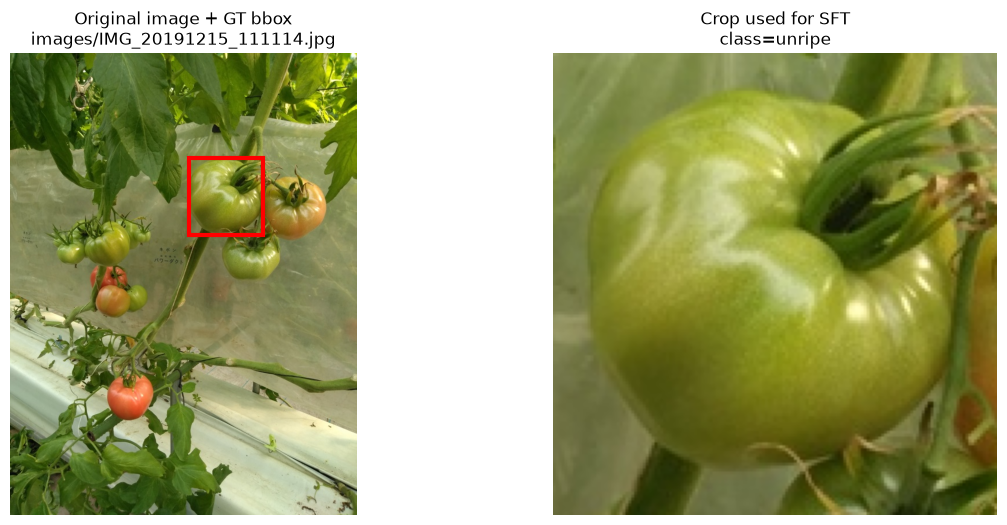

{
  "messages": [
    {
      "role": "system",
      "content": "You classify tomato ripeness from a detector crop. Always return strict JSON only. Do not add markdown or extra text."
    },
    {
      "role": "user",
      "content": "<image>\nClassify only the tomato shown in the crop image.\nUse the crop appearance as primary evidence.\n\nInput bbox JSON (copy these values exactly into output.bbox): {\"x1\": 309.58, \"y1\": 182.14, \"x2\": 437.03, \"y2\": 314.55}\n\nRipeness guide:\n- fully-ripe: red surface is dominant and continuous, with no residual green shoulder\n- semi-ripe: heterogeneous red-orange-green transition remains visible\n- unripe: green surface remains dominant\n- If illumination, shadow, blur, or occlusion makes fully-ripe vs semi-ripe ambiguous, choose semi-ripe.\nReturn JSON that follows this schema exactly:\n{\n  \"class_name\": one of [\"fully-ripe\", \"semi-ripe\", \"unripe\"],\n  \"bbox\": {\"x1\": number, \"y1\": number, \"x2\": number, \"y2\": number},\n

In [33]:
PREVIEW_INDEX = 0

preview_record = train_records[PREVIEW_INDEX]
preview_crop = load_crop(
    preview_record,
    expand_ratio=float(EXPAND_RATIO),
    min_size=int(MIN_SIZE),
)

with Image.open(preview_record["image_path"]) as handle:
    original = ImageOps.exif_transpose(handle).convert("RGB")

x1, y1, x2, y2 = [float(value) for value in preview_record["bbox_xyxy"]]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(original)
axes[0].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=3, edgecolor="red"))
axes[0].set_title(f"Original image + GT bbox\n{preview_record['file_name']}")
axes[0].axis("off")

axes[1].imshow(preview_crop)
axes[1].set_title(f"Crop used for SFT\nclass={preview_record['class_name']}")
axes[1].axis("off")
plt.show()

preview_row = build_training_row(preview_record, Path("/tmp/example_crop.jpg"))
print(json.dumps(preview_row, indent=2, ensure_ascii=False))

## Conversion

아래 셀은 실제로 학습용 crop 이미지와 `ms-swift`용 JSONL을 만든다.

생성 포맷은 다음과 같다.

- `messages`: system / user / assistant
- `images`: crop 파일 경로 1개
- user content: `<image>` + 기존 `detect-and-reason` prompt 규칙
- assistant content: 현재 파이프라인이 기대하는 strict JSON

즉, **학습 때 쓰는 prompt와 추론 때 쓰는 prompt를 최대한 맞춘다**.

In [18]:
def write_jsonl(path: Path, rows: list[dict]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        for row in rows:
            handle.write(json.dumps(row, ensure_ascii=False))
            handle.write("\n")

def convert_split(records: list[dict], split_key: str, limit: int | None = None) -> list[dict]:
    selected = records if limit is None else records[:limit]
    crop_dir = CROP_OUTPUT_ROOT / split_key
    crop_dir.mkdir(parents=True, exist_ok=True)
    rows: list[dict] = []

    for index, record in enumerate(selected, start=1):
        crop = load_crop(
            record,
            expand_ratio=float(EXPAND_RATIO),
            min_size=int(MIN_SIZE),
        )
        crop_path = crop_dir / f"{record['sample_id']}.jpg"
        crop.save(crop_path, format="JPEG", quality=95)
        rows.append(build_training_row(record, crop_path))

        if index % 500 == 0 or index == len(selected):
            print(f"[{split_key}] converted {index}/{len(selected)}")
    return rows

if RUN_CONVERSION:
    train_rows = convert_split(train_records, "train", limit=MAX_TRAIN_SAMPLES)
    val_rows = convert_split(val_records, "val", limit=MAX_VAL_SAMPLES)

    write_jsonl(TRAIN_JSONL, train_rows)
    write_jsonl(VAL_JSONL, val_rows)

    manifest = {
        "dataset_ref": DATASET_REF,
        "class_mode": CLASS_MODE,
        "model_id": MODEL_ID,
        "reasoning_style": REASONING_STYLE,
        "train_jsonl": str(TRAIN_JSONL),
        "val_jsonl": str(VAL_JSONL),
        "crop_root": str(CROP_OUTPUT_ROOT),
        "train_rows": len(train_rows),
        "val_rows": len(val_rows),
    }
    MANIFEST_JSON.parent.mkdir(parents=True, exist_ok=True)
    MANIFEST_JSON.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")

    print(f"saved train jsonl = {TRAIN_JSONL}")
    print(f"saved val jsonl   = {VAL_JSONL}")
    print(f"saved manifest    = {MANIFEST_JSON}")
else:
    print("RUN_CONVERSION=False")
    print(f"train jsonl target = {TRAIN_JSONL}")
    print(f"val jsonl target   = {VAL_JSONL}")
    print(f"crop root target   = {CROP_OUTPUT_ROOT}")
    if TRAIN_JSONL.exists():
        print("existing train jsonl already exists")
    if VAL_JSONL.exists():
        print("existing val jsonl already exists")

[train] converted 500/11730
[train] converted 1000/11730
[train] converted 1500/11730
[train] converted 2000/11730
[train] converted 2500/11730
[train] converted 3000/11730
[train] converted 3500/11730
[train] converted 4000/11730
[train] converted 4500/11730
[train] converted 5000/11730
[train] converted 5500/11730
[train] converted 6000/11730
[train] converted 6500/11730
[train] converted 7000/11730
[train] converted 7500/11730
[train] converted 8000/11730
[train] converted 8500/11730
[train] converted 9000/11730
[train] converted 9500/11730
[train] converted 10000/11730
[train] converted 10500/11730
[train] converted 11000/11730
[train] converted 11500/11730
[train] converted 11730/11730
[val] converted 500/671
[val] converted 671/671
saved train jsonl = /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/train.jsonl
saved val jsonl   = /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/val.jsonl
saved manifest    = /home/hyeonjin/detect-

## Training Command

여기서는 `decoder-only first`에 맞는 `ms-swift` SFT command를 만든다.

핵심 설정:
- `--train_type lora`
- `--target_modules all-linear`
- `--freeze_vit true`
- `--freeze_aligner true`
- `--freeze_llm false`

이 조합이면 멀티모달 모델에서 기본적으로 **LLM component 쪽에만 tuner를 붙이는 baseline**이 된다.

주의:
- 현재 이 머신의 NVIDIA driver는 `CUDA 12.8`이므로, `torch/torchvision/torchaudio`도 `cu128` wheel 조합이어야 GPU를 잡는다.
- `ms-swift` 설치 직후 `torch.cuda.is_available()`가 `False`이면, `cu130` wheel이 들어갔는지 먼저 확인한다.

In [36]:
def build_swift_sft_command() -> list[str]:
    cmd = [
        resolve_swift_cmd(),
        "sft",
        "--model", MODEL_ID,
        "--tuner_type", "lora",
        "--dataset", str(TRAIN_JSONL),
        "--val_dataset", str(VAL_JSONL),
        "--output_dir", str(TRAIN_OUTPUT_DIR),
        "--torch_dtype", TORCH_DTYPE,
        "--num_train_epochs", str(NUM_TRAIN_EPOCHS),
        "--per_device_train_batch_size", str(PER_DEVICE_TRAIN_BATCH_SIZE),
        "--per_device_eval_batch_size", str(PER_DEVICE_EVAL_BATCH_SIZE),
        "--gradient_accumulation_steps", str(GRADIENT_ACCUMULATION_STEPS),
        "--learning_rate", str(LEARNING_RATE),
        "--lora_rank", str(LORA_RANK),
        "--lora_alpha", str(LORA_ALPHA),
        "--lora_dropout", str(LORA_DROPOUT),
        "--target_modules", "all-linear",
        "--freeze_vit", "true",
        "--freeze_aligner", "true",
        "--freeze_llm", "false",
        "--max_length", str(MAX_LENGTH),
        "--dataset_num_proc", str(DATASET_NUM_PROC),
        "--save_steps", str(SAVE_STEPS),
        "--eval_steps", str(EVAL_STEPS),
        "--logging_steps", str(LOGGING_STEPS),
        "--save_total_limit", str(SAVE_TOTAL_LIMIT),
    ]
    if USE_HF:
        cmd.extend(["--use_hf", "true"])
    if MAX_PIXELS is not None:
        cmd.extend(["--max_pixels", str(MAX_PIXELS)])
    return cmd


In [38]:
train_cmd = build_swift_sft_command()
print(shlex.join(train_cmd))


/home/hyeonjin/detect-and-reason/.venv/bin/swift sft --model Qwen/Qwen3-VL-4B-Instruct --tuner_type lora --dataset /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/train.jsonl --val_dataset /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/val.jsonl --output_dir /home/hyeonjin/detect-and-reason/notebook/result/vlm_sft/merge/qwen3_vl_4b_decoder_lora --torch_dtype bfloat16 --num_train_epochs 2 --per_device_train_batch_size 2 --per_device_eval_batch_size 2 --gradient_accumulation_steps 8 --learning_rate 0.0001 --lora_rank 16 --lora_alpha 32 --lora_dropout 0.05 --target_modules all-linear --freeze_vit true --freeze_aligner true --freeze_llm false --max_length 1024 --dataset_num_proc 4 --save_steps 200 --eval_steps 200 --logging_steps 10 --save_total_limit 2 --use_hf true


In [42]:
import os
import shlex
import subprocess

train_env = os.environ.copy()
train_env["CUDA_VISIBLE_DEVICES"] = "5"

print("CUDA_VISIBLE_DEVICES =", train_env.get("CUDA_VISIBLE_DEVICES"))
print(shlex.join(train_cmd))


CUDA_VISIBLE_DEVICES = 5
/home/hyeonjin/detect-and-reason/.venv/bin/swift sft --model Qwen/Qwen3-VL-4B-Instruct --tuner_type lora --dataset /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/train.jsonl --val_dataset /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/val.jsonl --output_dir /home/hyeonjin/detect-and-reason/notebook/result/vlm_sft/merge/qwen3_vl_4b_decoder_lora --torch_dtype bfloat16 --num_train_epochs 2 --per_device_train_batch_size 2 --per_device_eval_batch_size 2 --gradient_accumulation_steps 8 --learning_rate 0.0001 --lora_rank 16 --lora_alpha 32 --lora_dropout 0.05 --target_modules all-linear --freeze_vit true --freeze_aligner true --freeze_llm false --max_length 1024 --dataset_num_proc 4 --save_steps 200 --eval_steps 200 --logging_steps 10 --save_total_limit 2 --use_hf true


In [43]:
if RUN_INSTALL_MS_SWIFT:
    subprocess.run([sys.executable, "-m", "pip", "install", "-U", "ms-swift"], check=True)

if RUN_TRAINING:
    assert TRAIN_JSONL.exists(), "Run conversion first so train.jsonl exists."
    assert VAL_JSONL.exists(), "Run conversion first so val.jsonl exists."
    TRAIN_OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(train_cmd, check=True, cwd=PROJECT_ROOT)
else:
    print("RUN_TRAINING=False")
    print("Command only. Toggle RUN_TRAINING=True after dataset conversion and environment check.")

run sh: `/home/hyeonjin/detect-and-reason/.venv/bin/python /home/hyeonjin/detect-and-reason/.venv/lib/python3.12/site-packages/swift/cli/sft.py --model Qwen/Qwen3-VL-4B-Instruct --tuner_type lora --dataset /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/train.jsonl --val_dataset /home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/val.jsonl --output_dir /home/hyeonjin/detect-and-reason/notebook/result/vlm_sft/merge/qwen3_vl_4b_decoder_lora --torch_dtype bfloat16 --num_train_epochs 2 --per_device_train_batch_size 2 --per_device_eval_batch_size 2 --gradient_accumulation_steps 8 --learning_rate 0.0001 --lora_rank 16 --lora_alpha 32 --lora_dropout 0.05 --target_modules all-linear --freeze_vit true --freeze_aligner true --freeze_llm false --max_length 1024 --dataset_num_proc 4 --save_steps 200 --eval_steps 200 --logging_steps 10 --save_total_limit 2 --use_hf true`


[INFO:swift] Successfully registered `/home/hyeonjin/detect-and-reason/.venv/lib/python3.12/site-packages/swift/dataset/data/dataset_info.json`.
[INFO:swift] rank: -1, local_rank: -1, world_size: 1, local_world_size: 1
[INFO:swift] Downloading the model from HuggingFace Hub, model_id: Qwen/Qwen3-VL-4B-Instruct
Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 19336.02it/s]
[INFO:swift] Loading the model using model_dir: /home/hyeonjin/.cache/huggingface/hub/models--Qwen--Qwen3-VL-4B-Instruct/snapshots/ebb281ec70b05090aa6165b016eac8ec08e71b17
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[WARNING:swift] Please install the package: `pip install "decord" -U`.
[INFO:swift] Because len(args.val_dataset) > 0, setting split_dataset_ratio: 0.0
[INFO:swift] Setting args.lazy_tokenize: True
[INFO:swift] Setting args.dataloader_num_workers: 1
[INFO:swift] output_dir: /home/hyeonjin/detect-and-reason/notebook/result/vlm_sft/merge/qwen3_vl_4b_decoder_lora/v6-20260703-201919

CalledProcessError: Command '['/home/hyeonjin/detect-and-reason/.venv/bin/swift', 'sft', '--model', 'Qwen/Qwen3-VL-4B-Instruct', '--tuner_type', 'lora', '--dataset', '/home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/train.jsonl', '--val_dataset', '/home/hyeonjin/detect-and-reason/data/vlm_sft/merge_3cls_qwen3_vl_decoder/val.jsonl', '--output_dir', '/home/hyeonjin/detect-and-reason/notebook/result/vlm_sft/merge/qwen3_vl_4b_decoder_lora', '--torch_dtype', 'bfloat16', '--num_train_epochs', '2', '--per_device_train_batch_size', '2', '--per_device_eval_batch_size', '2', '--gradient_accumulation_steps', '8', '--learning_rate', '0.0001', '--lora_rank', '16', '--lora_alpha', '32', '--lora_dropout', '0.05', '--target_modules', 'all-linear', '--freeze_vit', 'true', '--freeze_aligner', 'true', '--freeze_llm', 'false', '--max_length', '1024', '--dataset_num_proc', '4', '--save_steps', '200', '--eval_steps', '200', '--logging_steps', '10', '--save_total_limit', '2', '--use_

## What Changes Later

이 baseline이 끝나면 다음 확장은 같은 데이터셋 변환 코드를 그대로 두고 **학습 범위만 바꾸면 된다**.

1. `aligner(projector)`도 같이 적응시키고 싶으면:
- `--freeze_aligner false`

2. vision encoder까지 건드리고 싶으면:
- `--freeze_vit false`

3. `vLLM` 가속 추론까지 고려하면:
- 우선은 `QLoRA`보다 `LoRA`를 유지하는 편이 낫다
- `ms-swift` 문서상 merge 후 `vLLM/sglang/lmdeploy` inference 경로를 권장한다

4. `detect-and-reason` 레포에 실제 연결할 때 주의점:
- 현재 `src/vlm/backends/qwen_hf.py`는 base model 경로만 읽는다
- 그래서 다음 단계 코드는 둘 중 하나가 필요하다
- HF backend가 LoRA adapter를 직접 로드하게 확장
- 또는 merge/export된 full weights 경로를 backend에서 읽게 변경

정리하면, 이번 노트북의 역할은 **데이터 포맷을 고정하고 decoder-only baseline을 가장 먼저 검증하는 것**이다.

## Quick Inference Test with Trained LoRA Adapter

pipeline(`scripts/vlm_classification_pipeline.py`)에 바로 연결하기 전에, 노트북 안에서 학습된 adapter가 실제로 동작하는지 먼저 확인한다.

- base model(`Qwen/Qwen3-VL-4B-Instruct`) 위에 `peft.PeftModel.from_pretrained`로 방금 학습한 adapter만 얹는다 (merge 없음, 실험용 in-memory 로드)
- prompt/parsing은 실제 pipeline이 쓰는 `build_messages` / `load_crop` / `parse_vlm_response`를 그대로 재사용해서, 여기서 확인한 결과가 곧 pipeline에서 나올 결과와 같도록 맞춘다
- 결과가 괜찮으면 그다음 단계로 `config/vlm/qwen_finetune.yaml`에 adapter 경로를 추가하고 `src/vlm/backends/qwen_hf.py`를 확장해서 실제 pipeline에 연결한다 (merge 방식 vs peft 직접 로드 방식은 그때 다시 결정)

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "5"  # must run before torch/transformers touch CUDA; requires a fresh kernel

import torch
from peft import PeftModel
from transformers import AutoModelForImageTextToText, AutoProcessor
from qwen_vl_utils import process_vision_info

from src.vlm.json_utils import parse_vlm_response
from src.vlm.prompting import build_messages

print(f"CUDA_VISIBLE_DEVICES = {os.environ['CUDA_VISIBLE_DEVICES']}")

# 가장 최근 학습 run에서 나온 best checkpoint (trainer_state.json best_model_checkpoint 기준, eval_loss=0.00191)
ADAPTER_CHECKPOINT = Path(
    "/home/hyeonjin/detect-and-reason/notebook/results/vlm_sft/merge/"
    "qwen3_vl_4b_decoder_lora/v0-20260703-202247/checkpoint-1468"
)
assert ADAPTER_CHECKPOINT.exists(), f"checkpoint not found: {ADAPTER_CHECKPOINT}"

sft_base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)
sft_model = PeftModel.from_pretrained(sft_base_model, str(ADAPTER_CHECKPOINT))
sft_model.eval()

sft_processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
if sft_processor.tokenizer is not None:
    sft_processor.tokenizer.padding_side = "left"

print(f"adapter loaded from {ADAPTER_CHECKPOINT}")
print(f"device = {sft_model.device}")

In [ ]:
EVAL_SAMPLE_COUNT = 12
GENERATION_KWARGS = dict(max_new_tokens=220, do_sample=False, repetition_penalty=1.1)


@torch.inference_mode()
def generate_with_sft(messages_batch: list[list[dict]]) -> list[str]:
    texts = [
        sft_processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
        for m in messages_batch
    ]
    image_inputs: list = []
    for m in messages_batch:
        imgs, _videos = process_vision_info(m)
        if imgs:
            image_inputs.extend(imgs)
    inputs = sft_processor(
        text=texts,
        images=image_inputs or None,
        padding=True,
        return_tensors="pt",
    ).to(sft_model.device)
    outputs = sft_model.generate(**inputs, **GENERATION_KWARGS)
    decoded = [sft_processor.decode(o, skip_special_tokens=True) for o in outputs]
    return [d.split("assistant")[-1].strip() if "assistant" in d else d.strip() for d in decoded]


eval_records = val_records[:EVAL_SAMPLE_COUNT]
eval_rows = []
for record in eval_records:
    crop_image = load_crop(record, expand_ratio=float(EXPAND_RATIO), min_size=int(MIN_SIZE))
    messages = build_messages(record=record, crop_image=crop_image, prompt_cfg=prompt_cfg)
    raw_text = generate_with_sft([messages])[0]
    parsed = parse_vlm_response(
        text=raw_text,
        bbox_fallback_xyxy=[float(v) for v in record["bbox_xyxy"]],
        require_reasoning=bool(prompt_cfg.get("use_reasoning", True)),
    )
    eval_rows.append(
        {
            "sample_id": record["sample_id"],
            "gt_class": record["class_name"],
            "pred_class": parsed["class_name"],
            "correct": parsed["class_name"] == record["class_name"],
            "parse_error": parsed["parse_error"],
            "raw_response": raw_text,
        }
    )

eval_df = pd.DataFrame(eval_rows)
display(eval_df[["sample_id", "gt_class", "pred_class", "correct", "parse_error"]])
print(f"accuracy = {eval_df['correct'].mean():.3f} over {len(eval_df)} samples")